<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/H3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H3 - Ramadan and Search Interest Analysis

## Objective

- The objective of this notebook is to analyze whether search interest for dates increases during Ramadan compared to non-Ramadan periods.

## Hypothesis

- H₀: Ramadan does not significantly affect search interest for dates.

- H₁: Ramadan significantly affects search interest for dates.

## 1) Uploading Search Dataset

- Upload and load the Google Trends search dataset for analysis.

In [ ]:
import pandas as pd

# Upload search dataset
from google.colab import files
uploaded = files.upload()

# Load search dataset
df = pd.read_csv("search.csv")

Saving search.csv to search.csv


## 2) Data Cleaning

- This part converts the time column into date format and renames the columns for easier analysis.

In [ ]:
# Convert Time column to datetime format
df["Time"] = pd.to_datetime(df["Time"])

# Rename columns for easier use
df = df.rename(columns={"Time": "Date", "تمر": "Search"})

## 3) Creating Ramadan Variable

- This part creates a Ramadan variable to separate Ramadan months from non-Ramadan months.

In [ ]:
# Create Ramadan column and set default value as 0
df["Ramadan"] = 0

ramadan_periods = [
    ("2015-06-18", "2015-07-17"),
    ("2016-06-06", "2016-07-05"),
    ("2017-05-27", "2017-06-24"),
    ("2018-05-16", "2018-06-14"),
    ("2019-05-05", "2019-06-03"),
    ("2020-04-23", "2020-05-23"),
    ("2021-04-13", "2021-05-12"),
    ("2022-04-02", "2022-05-01"),
    ("2023-03-23", "2023-04-21"),
    ("2024-03-11", "2024-04-09"),
    ("2025-03-01", "2025-03-30"),
]

# Convert Ramadan dates into datetime format
ramadan_periods = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in ramadan_periods]

# Mark rows that fall during Ramadan as 1
for start, end in ramadan_periods:
    df.loc[(df["Date"] >= start) & (df["Date"] <= end), "Ramadan"] = 1

[(Timestamp('2015-06-18 00:00:00'), Timestamp('2015-07-17 00:00:00')),
 (Timestamp('2016-06-06 00:00:00'), Timestamp('2016-07-05 00:00:00')),
 (Timestamp('2017-05-27 00:00:00'), Timestamp('2017-06-24 00:00:00')),
 (Timestamp('2018-05-16 00:00:00'), Timestamp('2018-06-14 00:00:00')),
 (Timestamp('2019-05-05 00:00:00'), Timestamp('2019-06-03 00:00:00')),
 (Timestamp('2020-04-23 00:00:00'), Timestamp('2020-05-23 00:00:00')),
 (Timestamp('2021-04-13 00:00:00'), Timestamp('2021-05-12 00:00:00')),
 (Timestamp('2022-04-02 00:00:00'), Timestamp('2022-05-01 00:00:00')),
 (Timestamp('2023-03-23 00:00:00'), Timestamp('2023-04-21 00:00:00')),
 (Timestamp('2024-03-11 00:00:00'), Timestamp('2024-04-09 00:00:00')),
 (Timestamp('2025-03-01 00:00:00'), Timestamp('2025-03-30 00:00:00'))]

In [ ]:
# Display Ramadan observations
df[df["Ramadan"] == 1]

,Date,Search,Ramadan
138,2015-07-01,27,1
150,2016-07-01,24,1
161,2017-06-01,31,1
173,2018-06-01,32,1
185,2019-06-01,31,1
196,2020-05-01,46,1
208,2021-05-01,36,1
220,2022-05-01,37,1
231,2023-04-01,60,1
243,2024-04-01,50,1


## 5) Two-Sample T-Test

- This part tests whether average search interest is significantly different during Ramadan and non-Ramadan periods.

In [ ]:
from scipy.stats import ttest_ind

# Separate Ramadan and non-Ramadan search values
ramadan = df[df["Ramadan"] == 1]["Search"]
non_ramadan = df[df["Ramadan"] == 0]["Search"]

# Run independent two-sample t-test
t_stat, p_value = ttest_ind(ramadan, non_ramadan)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 2.24093030385465
p-value: 0.025855949743621924


## Results

- The t-test produced a t-statistic of 2.24 and a p-value of 0.0259.

- Since the p-value is less than 0.05, we reject the null hypothesis (H₀).

- This means there is enough statistical evidence to conclude that Ramadan has a significant effect on search interest for dates.

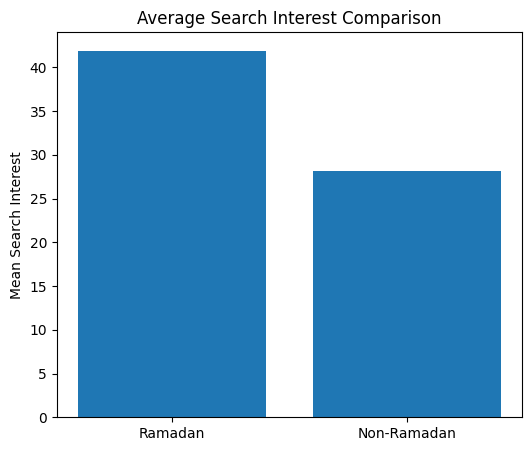

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate average search interest for both periods
ramadan_mean = np.mean(ramadan)
non_ramadan_mean = np.mean(non_ramadan)

plt.figure(figsize=(6,5))

# Create bar chart
plt.bar(["Ramadan", "Non-Ramadan"], [ramadan_mean, non_ramadan_mean])

plt.title("Average Search Interest Comparison")
plt.ylabel("Mean Search Interest")

plt.show()

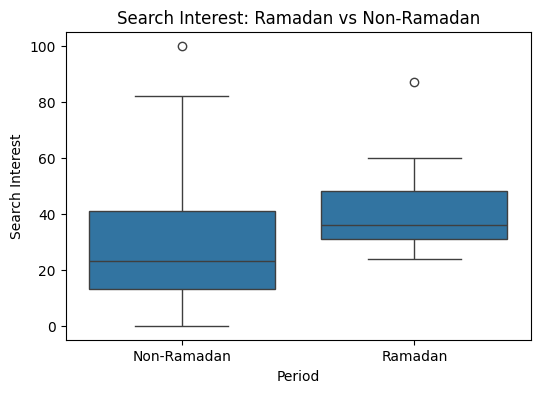

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))

# Create boxplot comparing both periods
sns.boxplot(x="Ramadan", y="Search", data=df)

plt.xticks([0, 1], ["Non-Ramadan", "Ramadan"])
plt.xlabel("Period")
plt.ylabel("Search Interest")
plt.title("Search Interest: Ramadan vs Non-Ramadan")

plt.show()

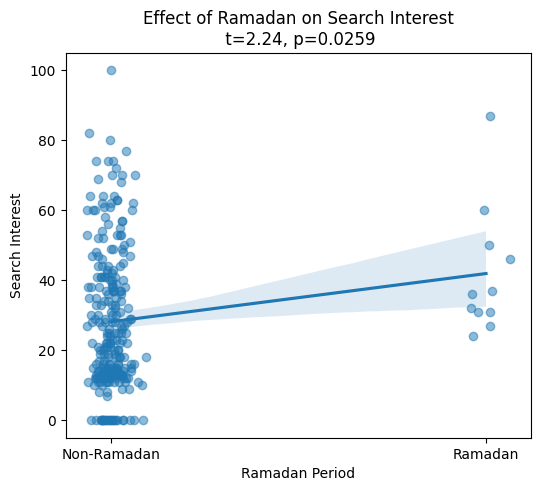

In [ ]:
# Add small random noise so points do not overlap
jitter = np.random.normal(0, 0.03, size=len(df))

plt.figure(figsize=(6,5))

# Create scatter plot
plt.scatter(df["Ramadan"] + jitter, df["Search"], alpha=0.5)

# Add regression line
sns.regplot(x="Ramadan", y="Search", data=df, scatter=False)

plt.xticks([0,1], ["Non-Ramadan", "Ramadan"])
plt.title(f"Effect of Ramadan on Search Interest\n t={t_stat:.2f}, p={p_value:.4f}")
plt.xlabel("Ramadan Period")
plt.ylabel("Search Interest")

plt.show()